# CREDIT CARD FRAUD DETECTION - MACHINE LEARNING PIPELINE

In [26]:
!pip install seaborn xgboost lightgbm catboost imbalanced-learn shap streamlit joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
from sklearn.ensemble import ExtraTreesClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler


Defaulting to user installation because normal site-packages is not writeable


## 1. DATA LOADING

In [27]:
import pandas as pd

file_path = "creditcard.csv"
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. EXPLORATORY DATA ANALYSIS (EDA)


--- Class Distribution Analysis (Class Distribution) ---
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


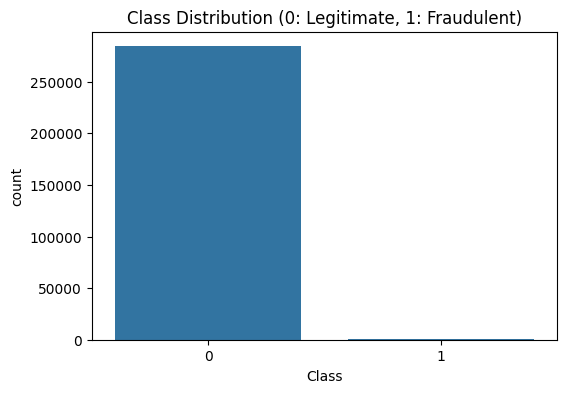


--- Feature Distribution Analysis (Feature Distribution) ---


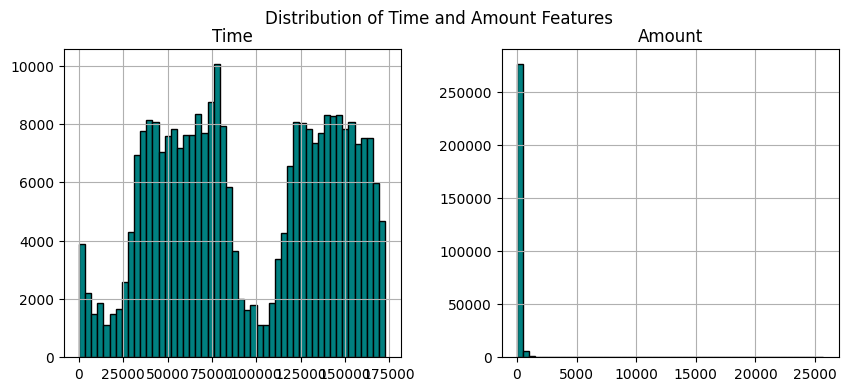


--- Correlation Analysis (Correlation Analysis) ---


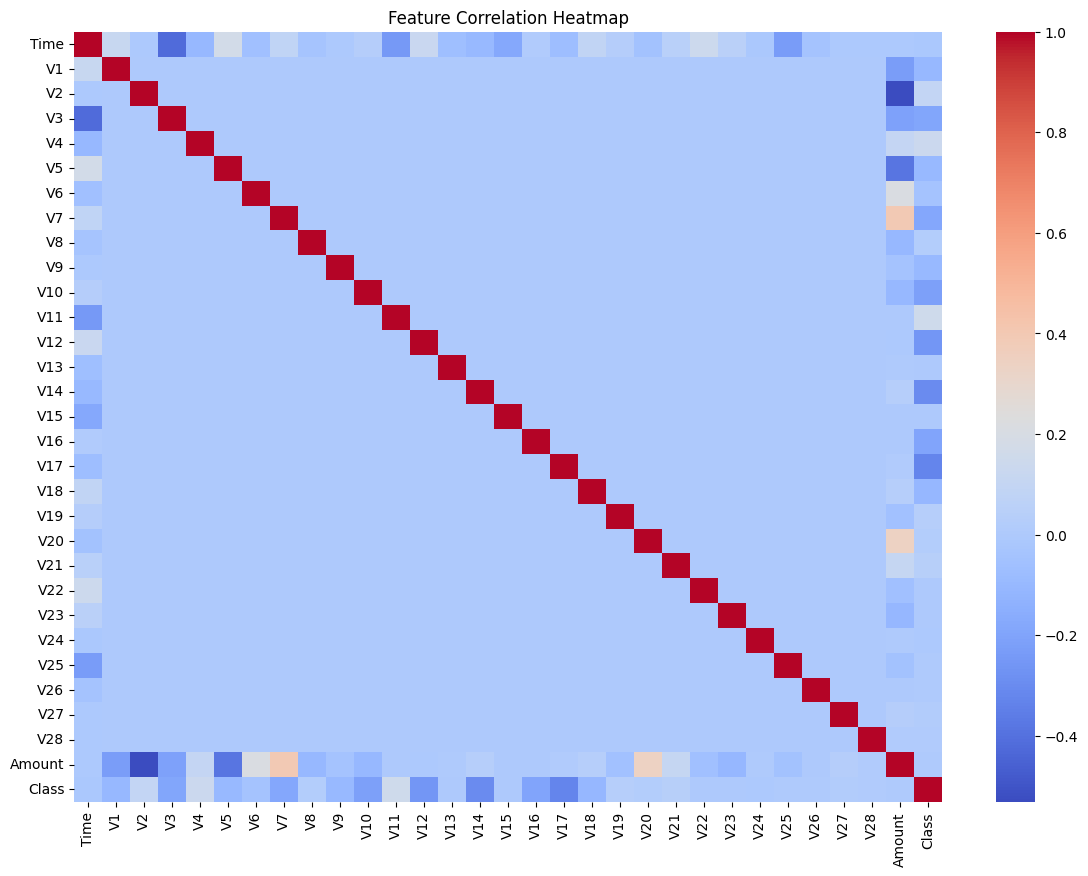

In [28]:
# 2. EXPLORATORY DATA ANALYSIS (EDA)
print("\n--- Class Distribution Analysis (Class Distribution) ---")
print(df['Class'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0: Legitimate, 1: Fraudulent)')
plt.show()

print("\n--- Feature Distribution Analysis (Feature Distribution) ---")
df[['Time','Amount']].hist(figsize=(10,4), bins=50, color='teal', edgecolor='black')
plt.suptitle('Distribution of Time and Amount Features')
plt.show()

print("\n--- Correlation Analysis (Correlation Analysis) ---")
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()



In [29]:
print("\n--- Dataset Information ---")
print("Dataset Shape:", df.shape)

fraud_count = (df['Class'] == 1).sum()
normal_count = (df['Class'] == 0).sum()

print(f"Normal Transactions: {normal_count:,}")
print(f"Fraud Transactions: {fraud_count:,}")
print(f"Fraud Percentage: {(fraud_count/len(df))*100:.4f}%")


--- Dataset Information ---
Dataset Shape: (284807, 31)
Normal Transactions: 284,315
Fraud Transactions: 492
Fraud Percentage: 0.1727%


## 3. DATA PREPROCESSING

In [30]:
# 3. DATA PREPROCESSING

print("\n--- Missing Values Analysis (Missing Values Analysis) ---")
missing = df.isnull().sum()
missing_cols = missing[missing > 0]

if missing_cols.empty:
    print("No missing values detected in the dataset.")
else:
    print("Columns containing missing values:")
    print(missing_cols)

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


--- Missing Values Analysis (Missing Values Analysis) ---
No missing values detected in the dataset.


## 4. CLASS IMBALANCE HANDLING

In [31]:
# 4. CLASS IMBALANCE HANDLING
datasets = {}
datasets['Original'] = (X_train, y_train)
datasets['SMOTE'] = SMOTE(random_state=42).fit_resample(X_train, y_train)
datasets['ADASYN'] = ADASYN(random_state=42).fit_resample(X_train, y_train)
datasets['UnderSampling'] = RandomUnderSampler(random_state=42).fit_resample(X_train, y_train)

scale_weight = (y_train == 0).sum() / (y_train == 1).sum()


## 5. MODEL INITIALIZATION

In [32]:
# 5. MODEL INITIALIZATION

models = {
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42),
    'XGBoost_ClassWeight': XGBClassifier(scale_pos_weight=scale_weight, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42),
    'CatBoost': CatBoostClassifier(iterations=300, learning_rate=0.05, verbose=0, random_state=42),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=300, random_state=42)
}


## 6. MODEL TRAINING AND EVALUATION

In [33]:
# 6. MODEL TRAINING AND EVALUATION
results = []
trained_models = {} # Dictionary lưu trữ model an toàn

print("\nTraining machine learning models. Please wait...\n")

for dataset_name, (Xtr, ytr) in datasets.items():
    for model_name, model in models.items():
        if model_name == 'XGBoost_ClassWeight' and dataset_name != 'Original':
            continue

        print(f"Training: {model_name} + {dataset_name}...")

        # Huấn luyện
        model.fit(Xtr, ytr)

        # Lưu model đã fit vào dictionary
        trained_models[(dataset_name, model_name)] = model

        # Dự đoán
        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)[:, 1]

        results.append({
            'Dataset': dataset_name,
            'Model': model_name,
            'Precision': precision_score(y_test, pred),
            'Recall': recall_score(y_test, pred),
            'F1': f1_score(y_test, pred),
            'ROC_AUC': roc_auc_score(y_test, prob),
            'PR_AUC': average_precision_score(y_test, prob)
        })

results_df = pd.DataFrame(results)
results_df.to_csv('model_comparison.csv', index=False)



Training machine learning models. Please wait...

Training: XGBoost + Original...
Training: XGBoost_ClassWeight + Original...
Training: LightGBM + Original...
[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018346 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339
Training: CatBoost + Original...
Training: ExtraTrees + Original...
Training: XGBoost + SMOTE...
Training: LightGBM + SMOTE...
[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing 

## 7. RESULTS SUMMARY AND BEST MODEL SELECTION


MODEL PERFORMANCE COMPARISON


,Dataset,Model,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Original,XGBoost,0.931818,0.836735,0.881720,0.978895,0.883578
8,SMOTE,ExtraTrees,0.912088,0.846939,0.878307,0.980480,0.880831
1,Original,XGBoost_ClassWeight,0.881720,0.836735,0.858639,0.968238,0.880004
12,ADASYN,ExtraTrees,0.911111,0.836735,0.872340,0.975585,0.878394
4,Original,ExtraTrees,0.952941,0.826531,0.885246,0.961492,0.875926
3,Original,CatBoost,0.916667,0.785714,0.846154,0.980478,0.873843
5,SMOTE,XGBoost,0.526946,0.897959,0.664151,0.980027,0.865794
6,SMOTE,LightGBM,0.648855,0.867347,0.742358,0.948285,0.835551
7,SMOTE,CatBoost,0.399083,0.887755,0.550633,0.980512,0.832180
9,ADASYN,XGBoost,0.382883,0.867347,0.531250,0.977232,0.830179



🏆 BEST MODEL (BASED ON PR-AUC) 🏆
Model: XGBoost
Dataset: Original
PR-AUC: 0.8836


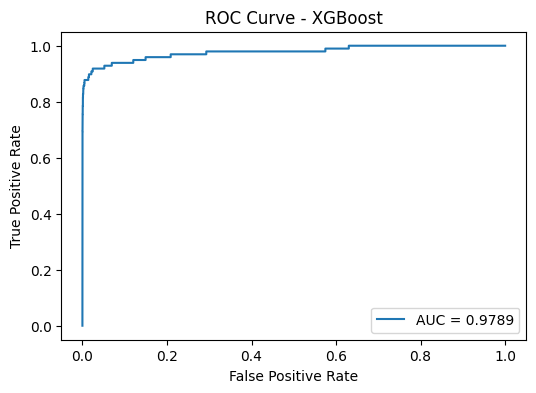

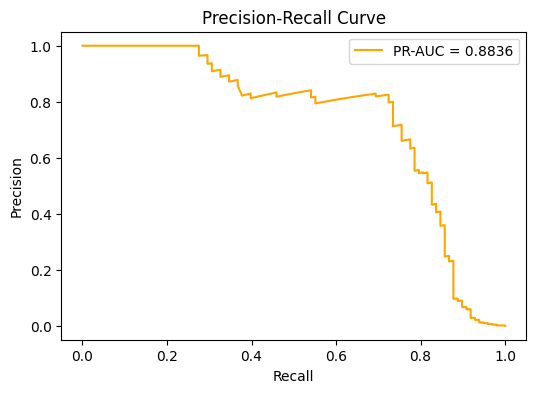

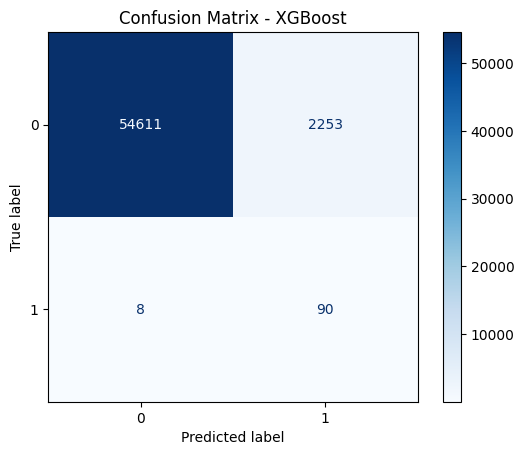

In [34]:
# 7. RESULTS SUMMARY AND BEST MODEL SELECTION
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
# Sắp xếp và hiển thị bảng đẹp mắt
display_df = results_df.sort_values(by='PR_AUC', ascending=False)
display(display_df)

# Lấy thông tin model tốt nhất
best_row = display_df.iloc[0]

print("\n" + "="*40)
print("🏆 BEST MODEL (BASED ON PR-AUC) 🏆")
print("="*40)
print(f"Model: {best_row['Model']}")
print(f"Dataset: {best_row['Dataset']}")
print(f"PR-AUC: {best_row['PR_AUC']:.4f}")
print("="*40)

# Truy xuất Best Model an toàn từ Dictionary
best_model = trained_models[(best_row['Dataset'], best_row['Model'])]

prob = best_model.predict_proba(X_test)[:, 1]
pred = best_model.predict(X_test)

# --- Trực quan hóa hiệu năng Best Model ---
fpr, tpr, _ = roc_curve(y_test, prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {best_row['ROC_AUC']:.4f}")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f"ROC Curve - {best_row['Model']}")
plt.legend()
plt.show()

precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)
plt.figure(figsize=(6,4))
plt.plot(recall_vals, precision_vals, color='orange', label=f"PR-AUC = {best_row['PR_AUC']:.4f}")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap='Blues')
plt.title(f'Confusion Matrix - {best_row["Model"]}')
plt.show()


## 8. EXPLAINABLE AI (SHAP)


Calculating SHAP values...


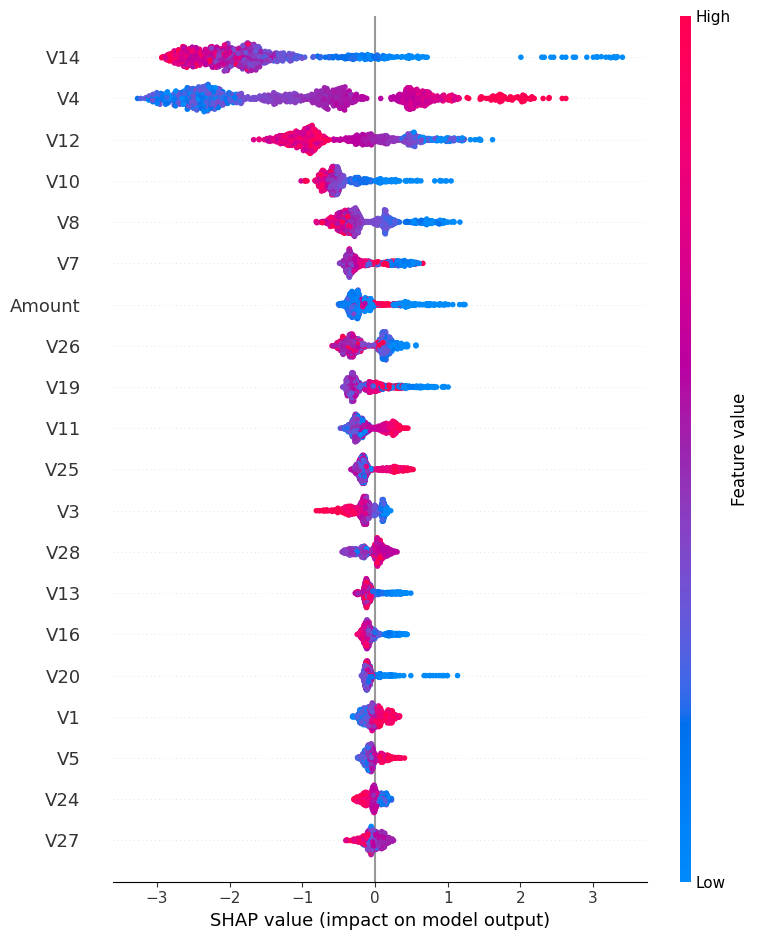

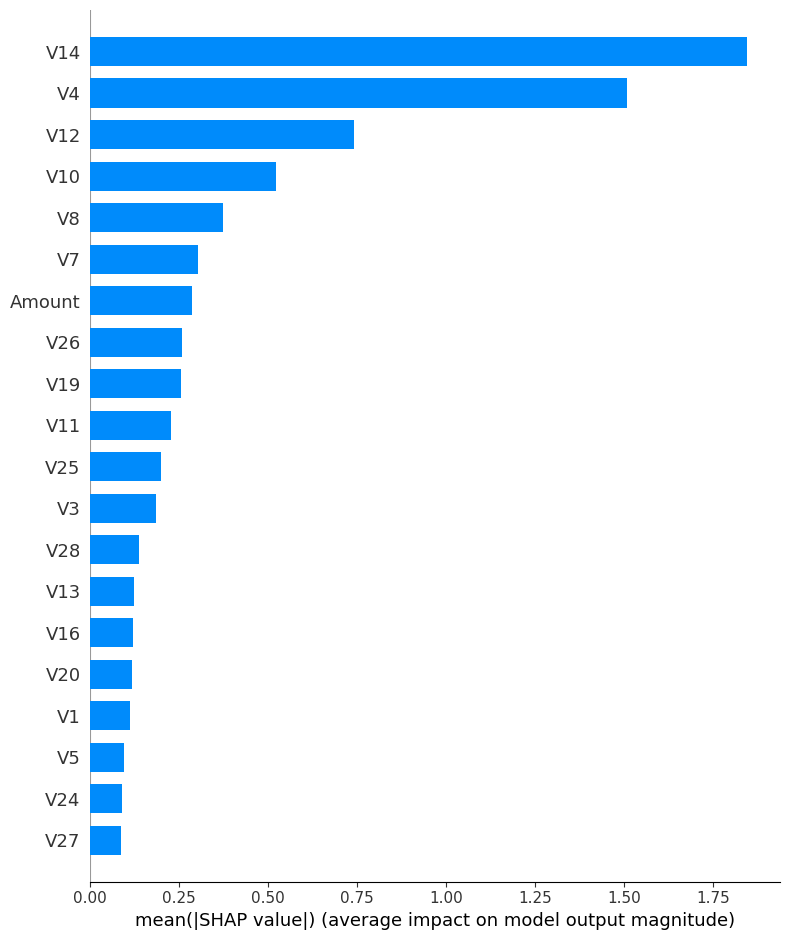

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)


In [35]:
# 8. EXPLAINABLE AI (SHAP)
print("\nCalculating SHAP values...")
sample = X_test.sample(min(1000, len(X_test)), random_state=42)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample)
shap.summary_plot(shap_values, sample, plot_type='bar')

print(best_model)


## 9. MODEL EXPORT AND DEPLOYMENT

In [36]:
from xgboost import XGBClassifier
import joblib

# 1. Khởi tạo mô hình XGBoost

final_xgb_model = XGBClassifier(
    random_state=42, 
    eval_metric='logloss', 
    n_jobs=-1
)

final_xgb_model.fit(X_train, y_train)

joblib.dump(final_xgb_model, 'fraud_model.pkl')
joblib.dump(scaler, 'scaler.pkl') 

print("'fraud_model.pkl' (XGBoost) và 'scaler.pkl' đã sẵn sàng.")

'fraud_model.pkl' (XGBoost) và 'scaler.pkl' đã sẵn sàng.
